In [13]:
dataset = openml.datasets.get_dataset(312)
X, _, _, _ = dataset.get_data(target=None)
label_cols = ["Beach", "Sunset", "FallFoliage", "Field", "Mountain", "Urban"]
attr_cols = [col for col in X.columns if 'attr' in col]
y = X[label_cols].values.astype(np.float32)
X = X[attr_cols]

X.shape

(2407, 294)

In [ ]:
import torch
from torch import nn, optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Standardize features ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X.values).astype(np.float32)

# --- Train (60%) / Val (20%) / Test (20%) ---
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y, test_size=0.4, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

# --- DataLoaders ---
BATCH_SIZE = 64

train_ds = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
val_ds   = TensorDataset(torch.from_numpy(X_val),   torch.from_numpy(y_val))
test_ds  = TensorDataset(torch.from_numpy(X_test),  torch.from_numpy(y_test))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=len(val_ds))
test_loader  = DataLoader(test_ds,  batch_size=len(test_ds))

INPUT_DIM  = X_train.shape[1]
N_LABELS   = y_train.shape[1]
print(f"Input dim: {INPUT_DIM}, Labels: {N_LABELS}")

Train: (1444, 294), Val: (481, 294), Test: (482, 294)
Input dim: 294, Labels: 6


In [7]:
class SharedOutputMLP(nn.Module):
    """MLP with a shared body and a single linear output layer for all labels."""

    def __init__(self, input_dim, hidden_dim, n_hidden, n_labels, activation="ReLU"):
        super().__init__()
        self.input_layer = nn.Linear(input_dim, hidden_dim)
        self.hidden_layers = nn.ModuleList(
            [nn.Linear(hidden_dim, hidden_dim) for _ in range(n_hidden)]
        )
        self.output_layer = nn.Linear(hidden_dim, n_labels)

        self.activation = nn.ReLU() if activation == "ReLU" else nn.Tanh()

    def forward(self, x):
        x = self.activation(self.input_layer(x))
        for layer in self.hidden_layers:
            x = self.activation(layer(x))
        return self.output_layer(x)  # raw logits


SharedOutputMLP(INPUT_DIM, 128, 2, N_LABELS)

SharedOutputMLP(
  (input_layer): Linear(in_features=294, out_features=128, bias=True)
  (hidden_layers): ModuleList(
    (0-1): 2 x Linear(in_features=128, out_features=128, bias=True)
  )
  (output_layer): Linear(in_features=128, out_features=6, bias=True)
  (activation): ReLU()
)

In [8]:
class IndependentHeadsMLP(nn.Module):
    """MLP with a shared body and independent per-label output heads."""

    def __init__(self, input_dim, hidden_dim, n_hidden, n_labels, activation="ReLU"):
        super().__init__()
        self.input_layer = nn.Linear(input_dim, hidden_dim)
        self.hidden_layers = nn.ModuleList(
            [nn.Linear(hidden_dim, hidden_dim) for _ in range(n_hidden)]
        )
        self.heads = nn.ModuleList(
            [nn.Linear(hidden_dim, 1) for _ in range(n_labels)]
        )

        self.activation = nn.ReLU() if activation == "ReLU" else nn.Tanh()

    def forward(self, x):
        x = self.activation(self.input_layer(x))
        for layer in self.hidden_layers:
            x = self.activation(layer(x))
        return torch.cat([head(x) for head in self.heads], dim=1)  # raw logits


IndependentHeadsMLP(INPUT_DIM, 128, 2, N_LABELS)

IndependentHeadsMLP(
  (input_layer): Linear(in_features=294, out_features=128, bias=True)
  (hidden_layers): ModuleList(
    (0-1): 2 x Linear(in_features=128, out_features=128, bias=True)
  )
  (heads): ModuleList(
    (0-5): 6 x Linear(in_features=128, out_features=1, bias=True)
  )
  (activation): ReLU()
)

In [9]:
import copy
from sklearn.metrics import hamming_loss, f1_score


class MultiLabelTrainer:
    """Trains and evaluates a multi-label model, following the ModelTrainer
    pattern from 3_Multilabel_classification.ipynb but adapted for
    BCEWithLogitsLoss and multi-label metrics."""

    def __init__(
        self,
        model_class: type,
        model_params: dict,
        train_loader: DataLoader,
        val_loader: DataLoader,
        device: torch.device,
        lr: float = 1e-3,
        num_epochs: int = 100,
    ):
        self.model = model_class(**model_params).to(device)
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.device = device
        self.lr = lr
        self.num_epochs = num_epochs

        self.criterion = nn.BCEWithLogitsLoss()
        self.optimizer = optim.Adam(self.model.parameters(), lr=lr)

        self.best_state = None
        self.history = {"train_loss": [], "val_loss": []}

    # ------ private helpers --------------------------------------------------

    def _train_one_epoch(self):
        self.model.train()
        running_loss = 0.0
        for X_b, y_b in self.train_loader:
            X_b, y_b = X_b.to(self.device), y_b.to(self.device)
            self.optimizer.zero_grad()
            loss = self.criterion(self.model(X_b), y_b)
            loss.backward()
            self.optimizer.step()
            running_loss += loss.item()
        return running_loss / len(self.train_loader)

    @torch.no_grad()
    def _calculate_val_loss(self):
        self.model.eval()
        running_loss = 0.0
        for X_b, y_b in self.val_loader:
            X_b, y_b = X_b.to(self.device), y_b.to(self.device)
            running_loss += self.criterion(self.model(X_b), y_b).item()
        return running_loss / len(self.val_loader)

    # ------ public API -------------------------------------------------------

    def train(self) -> dict:
        best_val_loss = float("inf")

        for epoch in range(self.num_epochs):
            train_loss = self._train_one_epoch()
            val_loss = self._calculate_val_loss()

            self.history["train_loss"].append(train_loss)
            self.history["val_loss"].append(val_loss)

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                self.best_state = copy.deepcopy(self.model.state_dict())

        self.model.load_state_dict(self.best_state)
        print(f"Training done — best val loss: {best_val_loss:.4f}")
        return self.history

    @torch.no_grad()
    def evaluate(self, loader: DataLoader) -> dict:
        """Compute loss and multi-label metrics on an arbitrary loader."""
        self.model.eval()
        all_logits, all_targets = [], []

        running_loss = 0.0
        for X_b, y_b in loader:
            X_b, y_b = X_b.to(self.device), y_b.to(self.device)
            logits = self.model(X_b)
            running_loss += self.criterion(logits, y_b).item()
            all_logits.append(logits.cpu())
            all_targets.append(y_b.cpu())

        logits = torch.cat(all_logits)
        targets = torch.cat(all_targets).numpy().astype(int)
        preds = (torch.sigmoid(logits) > 0.5).numpy().astype(int)

        return {
            "loss":         running_loss / len(loader),
            "hamming_loss": hamming_loss(targets, preds),
            "micro_f1":     f1_score(targets, preds, average="micro", zero_division=0),
            "macro_f1":     f1_score(targets, preds, average="macro", zero_division=0),
        }

    @staticmethod
    def plot_loss(history: dict, title: str = ""):
        plt.figure(figsize=(8, 4))
        plt.plot(history["train_loss"], label="Train")
        plt.plot(history["val_loss"],   label="Val")
        plt.xlabel("Epoch")
        plt.ylabel("BCEWithLogitsLoss")
        plt.title(f"Loss curve — {title}" if title else "Loss curve")
        plt.legend()
        plt.tight_layout()
        plt.show()

SharedOutputMLP
Training done — best val loss: 0.1949


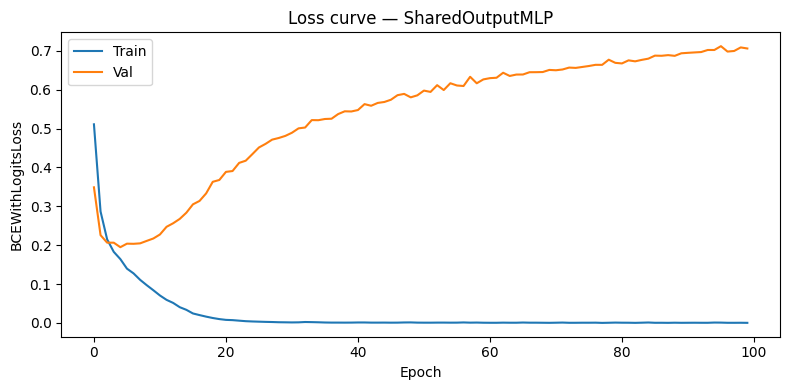

IndependentHeadsMLP
Training done — best val loss: 0.1983


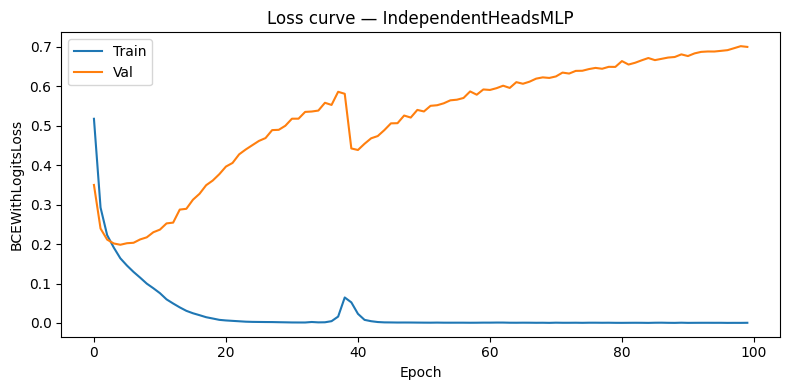

In [10]:
# Shared hyperparameters for both architectures
HIDDEN_DIM  = 128
N_HIDDEN    = 2
ACTIVATION  = "ReLU"
LR          = 1e-3
NUM_EPOCHS  = 100

model_params = dict(
    input_dim=INPUT_DIM,
    hidden_dim=HIDDEN_DIM,
    n_hidden=N_HIDDEN,
    n_labels=N_LABELS,
    activation=ACTIVATION,
)

# --- Shared-output model ---
print("=" * 50)
print("SharedOutputMLP")
print("=" * 50)
shared_trainer = MultiLabelTrainer(
    SharedOutputMLP, model_params, train_loader, val_loader,
    DEVICE, lr=LR, num_epochs=NUM_EPOCHS,
)
shared_history = shared_trainer.train()
MultiLabelTrainer.plot_loss(shared_history, "SharedOutputMLP")

# --- Independent-heads model ---
print("=" * 50)
print("IndependentHeadsMLP")
print("=" * 50)
heads_trainer = MultiLabelTrainer(
    IndependentHeadsMLP, model_params, train_loader, val_loader,
    DEVICE, lr=LR, num_epochs=NUM_EPOCHS,
)
heads_history = heads_trainer.train()
MultiLabelTrainer.plot_loss(heads_history, "IndependentHeadsMLP")

In [11]:
rows = []
for name, trainer in [("SharedOutputMLP", shared_trainer),
                       ("IndependentHeadsMLP", heads_trainer)]:
    for split, loader in [("val", val_loader), ("test", test_loader)]:
        metrics = trainer.evaluate(loader)
        rows.append({"Model": name, "Split": split, **metrics})

results_df = pd.DataFrame(rows)
results_df.style.format({
    "loss":         "{:.4f}",
    "hamming_loss": "{:.4f}",
    "micro_f1":     "{:.4f}",
    "macro_f1":     "{:.4f}",
})

,Model,Split,loss,hamming_loss,micro_f1,macro_f1
0,SharedOutputMLP,val,0.1949,0.0769,0.7744,0.7735
1,SharedOutputMLP,test,0.1768,0.0761,0.7713,0.7749
2,IndependentHeadsMLP,val,0.1983,0.0748,0.7791,0.7803
3,IndependentHeadsMLP,test,0.1790,0.0757,0.7707,0.7742


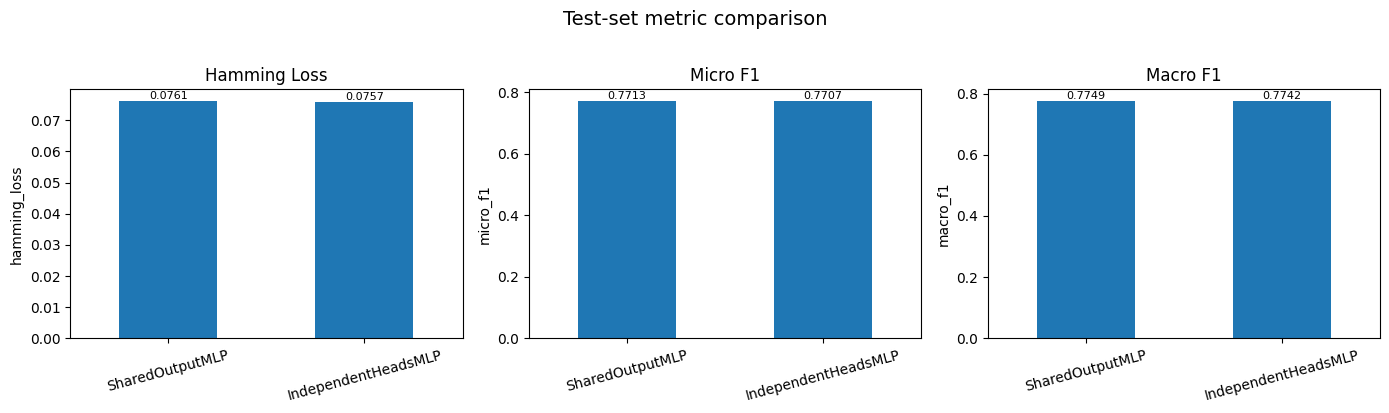

In [12]:
test_rows = results_df[results_df["Split"] == "test"].set_index("Model")
metrics_to_plot = ["hamming_loss", "micro_f1", "macro_f1"]

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(14, 4))

for ax, metric in zip(axes, metrics_to_plot):
    test_rows[metric].plot.bar(ax=ax, rot=15)
    ax.set_title(metric.replace("_", " ").title())
    ax.set_ylabel(metric)
    ax.set_xlabel("")
    for container in ax.containers:
        ax.bar_label(container, fmt="%.4f", fontsize=8)

fig.suptitle("Test-set metric comparison", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()